<a href="https://colab.research.google.com/github/41275030H/DIGITAL-CLOCK-WITH-THREE-FUNCTION-USING-FPGA-VERILOG-CODE/blob/main/task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# Sphere function (unimodal)
def sphere(x):
    return np.sum(x**2)

# Schwefel function (multimodal)
def schwefel(x):
    d = len(x)
    return 418.9829*d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

In [2]:
POP_SIZE = 50
DIM = 30
MAX_FE = 200000

LOWER_SPHERE, UPPER_SPHERE = -100, 100
LOWER_SCHWEFEL, UPPER_SCHWEFEL = -500, 500

CROSS_RATE = 0.8
MUT_RATE = 0.05

In [3]:
def init_population(size, dim, lower, upper):
    return np.random.uniform(lower, upper, (size, dim))

In [4]:
def selection(pop, fitness):
    i, j = np.random.randint(len(pop), size=2)
    return pop[i] if fitness[i] < fitness[j] else pop[j]

In [5]:
def crossover(p1, p2):
    if np.random.rand() < CROSS_RATE:
        alpha = np.random.rand()
        return alpha*p1 + (1-alpha)*p2
    return p1.copy()

In [6]:
def mutation(child, lower, upper):
    if np.random.rand() < MUT_RATE:
        child += np.random.normal(0, 1, size=len(child))
    return np.clip(child, lower, upper)

In [7]:
def run_GA(func, lower, upper):
    pop = init_population(POP_SIZE, DIM, lower, upper)
    FE = 0

    best_fitness_history = []

    while FE < MAX_FE:
        fitness = np.array([func(ind) for ind in pop])
        new_pop = []

        for _ in range(POP_SIZE):
            p1 = selection(pop, fitness)
            p2 = selection(pop, fitness)

            child = crossover(p1, p2)
            child = mutation(child, lower, upper)

            new_pop.append(child)

        pop = np.array(new_pop)
        FE += POP_SIZE

        best_fitness = np.min([func(ind) for ind in pop])
        best_fitness_history.append(best_fitness)

    best_solution = pop[np.argmin([func(ind) for ind in pop])]
    best_value = func(best_solution)

    return best_solution, best_value, best_fitness_history

In [8]:
# Sphere
best_sol_s, best_val_s, history_s = run_GA(sphere, -100, 100)

# Schwefel
best_sol_sw, best_val_sw, history_sw = run_GA(schwefel, -500, 500)

In [10]:
results_sphere = []

for i in range(10):
    _, val, _ = run_GA(sphere, -100, 100)
    results_sphere.append(val)

print("=== Sphere Function ===")
print("Mean:", np.mean(results_sphere))
print("Std:", np.std(results_sphere))

=== Sphere Function ===
Mean: 0.7937643543738508
Std: 0.1775042055681104


In [11]:
results_schwefel = []

for i in range(10):
    _, val, _ = run_GA(schwefel, -500, 500)
    results_schwefel.append(val)

print("\n=== Schwefel Function ===")
print("Mean:", np.mean(results_schwefel))
print("Std:", np.std(results_schwefel))


=== Schwefel Function ===
Mean: 8610.840098346178
Std: 1449.0149111979902


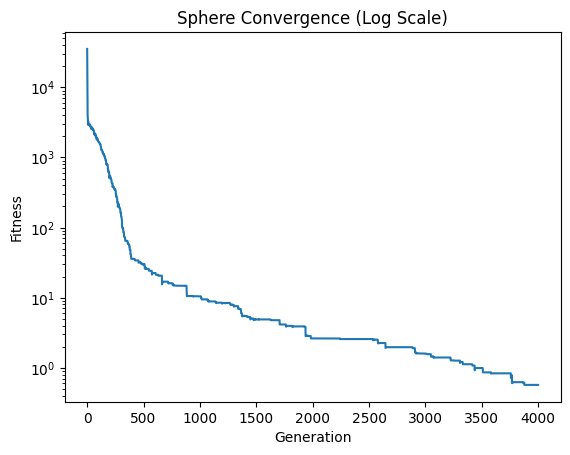

In [14]:
plt.plot(history_s)
plt.yscale('log')
plt.title("Sphere Convergence (Log Scale)")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.show()

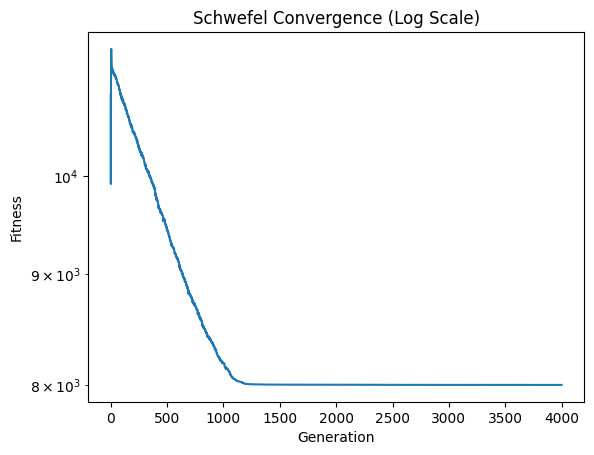

In [15]:
plt.plot(history_sw)
plt.yscale('log')
plt.title("Schwefel Convergence (Log Scale)")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.show()

In [17]:
def sphere_2d(x, y):
    return x**2 + y**2


In [18]:
import numpy as np

x = np.linspace(-100, 100, 200)
y = np.linspace(-100, 100, 200)

X, Y = np.meshgrid(x, y)
Z = sphere_2d(X, Y)

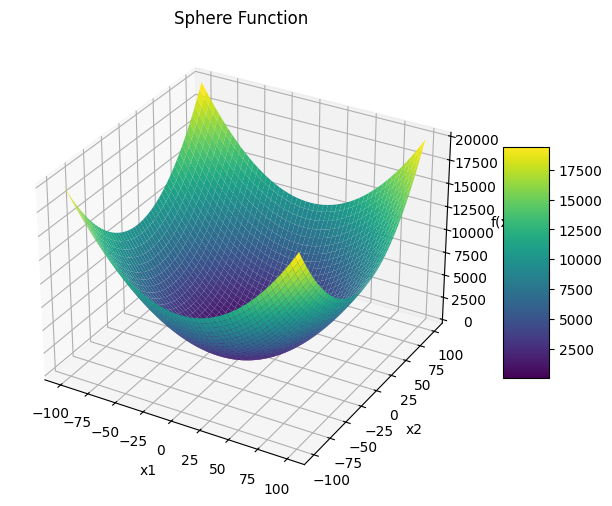

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_title("Sphere Function")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x)")

fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

In [20]:
def schwefel_2d(x, y):
    return 418.9829*2 - (x*np.sin(np.sqrt(abs(x))) + y*np.sin(np.sqrt(abs(y))))

In [21]:
x = np.linspace(-500, 500, 200)
y = np.linspace(-500, 500, 200)

X, Y = np.meshgrid(x, y)
Z = schwefel_2d(X, Y)

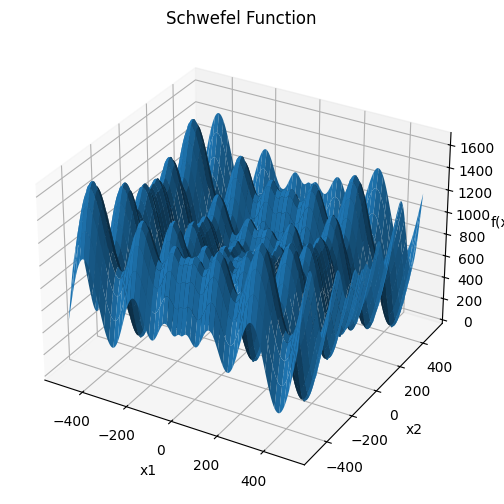

In [22]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

ax.set_title("Schwefel Function")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x)")

plt.show()